In [1]:
cd ..

/Users/matthewshen/Desktop/drd


In [ ]:
import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import umap
from drd.drd import DRD
import torch.nn as nn

/Users/matthewshen/.pyenv/versions/drd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/matthewshen/.pyenv/versions/drd/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewshen/.pyenv/versions/drd/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
100%|██████████| 100/100 [00:00<00:00, 249.17it/s]


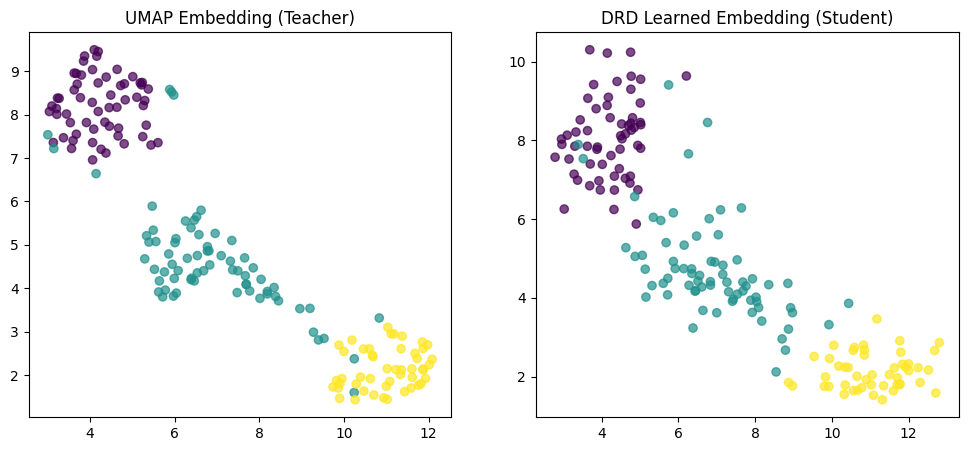

In [3]:
#wine

data = load_wine()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

student_model = DRD(input_dim=X_scaled.shape[1], latent_dim=2, lambda_d = 1, epochs=100, batch_size=32)

student_model.fit(X_scaled, teacher_Z=X_umap)

X_student = student_model.transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[0].set_title("UMAP Embedding (Teacher)")

axes[1].scatter(X_student[:, 0], X_student[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[1].set_title("DRD Learned Embedding (Student)")

plt.show()


/Users/matthewshen/.pyenv/versions/drd/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewshen/.pyenv/versions/drd/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
100%|██████████| 100/100 [00:00<00:00, 148.00it/s]


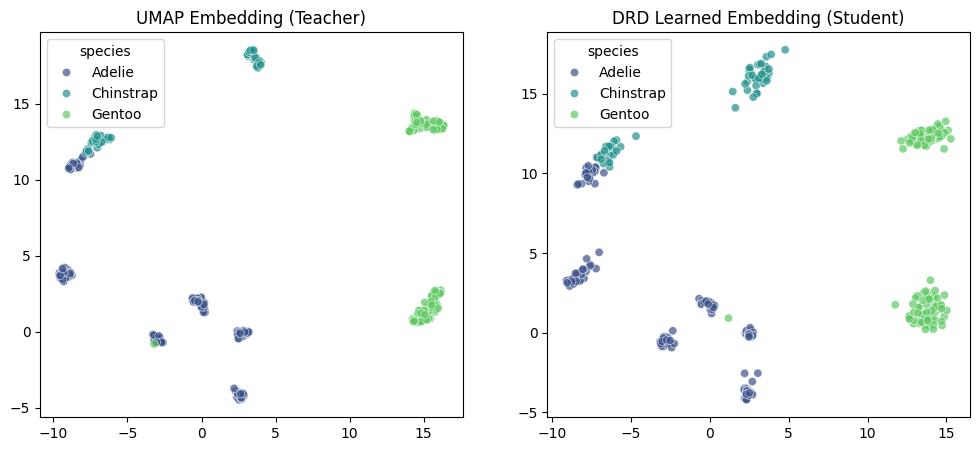

In [4]:
#penguins

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

df = df.dropna(subset=['species'])
num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_features = ["island", "sex"]
num_transformer = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler())
cat_transformer = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

X_processed = preprocessor.fit_transform(df)
y = df["species"].astype("category").cat.codes 

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_processed)


student_model = DRD(input_dim=X_processed.shape[1], latent_dim=2, lambda_d = 10, lambda_kl = 1, epochs=100, batch_size=32)

student_model.fit(X_processed, teacher_Z=X_umap)

X_student = student_model.transform(X_processed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df["species"], ax=axes[0], palette="viridis", alpha=0.7)
axes[0].set_title("UMAP Embedding (Teacher)")

sns.scatterplot(x=X_student[:, 0], y=X_student[:, 1], hue=df["species"], ax=axes[1], palette="viridis", alpha=0.7)
axes[1].set_title("DRD Learned Embedding (Student)")

plt.show()

100%|██████████| 100/100 [00:00<00:00, 142.85it/s]


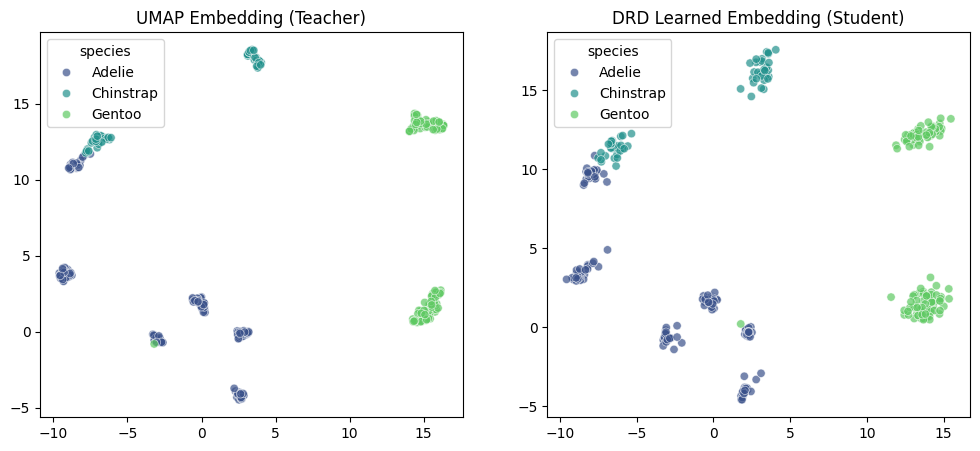

In [8]:
student_model = DRD(input_dim=X_processed.shape[1], latent_dim=2, lambda_d = 10, lambda_kl = 1, lambda_reg = 1e10000, epochs=100, batch_size=32)

student_model.fit(X_processed, teacher_Z=X_umap)

X_student = student_model.transform(X_processed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df["species"], ax=axes[0], palette="viridis", alpha=0.7)
axes[0].set_title("UMAP Embedding (Teacher)")

sns.scatterplot(x=X_student[:, 0], y=X_student[:, 1], hue=df["species"], ax=axes[1], palette="viridis", alpha=0.7)
axes[1].set_title("DRD Learned Embedding (Student)")

plt.show()